In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=fmax*2
paradigm = P300(resample=sfreq, tmin=0, tmax=0.7, fmin=0.5, fmax=fmax)
dataset = EPFLP300()

In [3]:
subject, session, run = 2, "session_1", "run_1"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
138 matching events found
No baseline correction applied


Number of events,138
Events,NonTarget: 115Target: 23
Time range,0.000 – 0.656 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


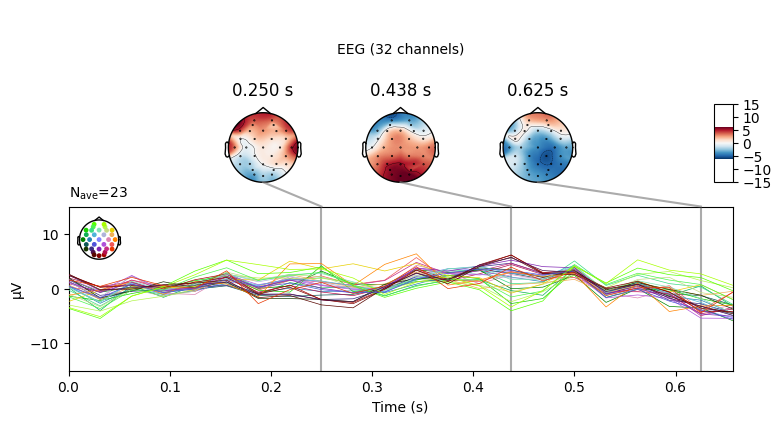

No projector specified for this dataset. Please consider the method self.add_proj.


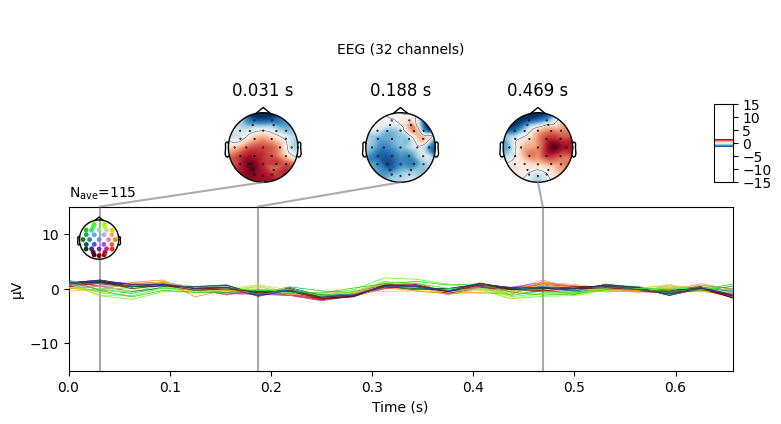

No projector specified for this dataset. Please consider the method self.add_proj.


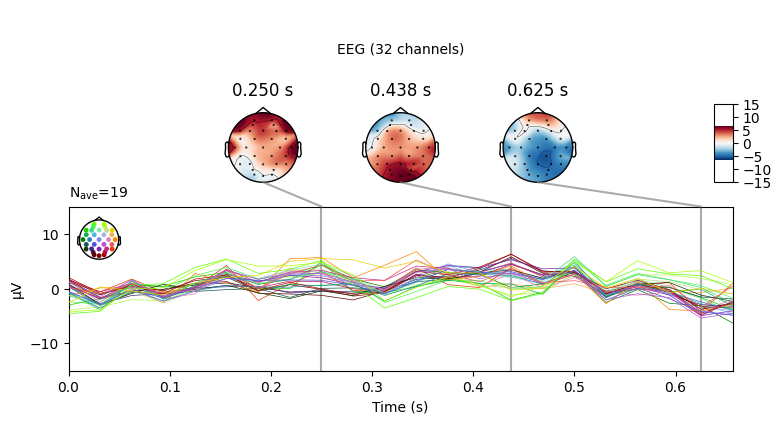

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
_ = target.plot_joint(ts_args=dict(ylim=dict(eeg=[-15,15])))
non_target = epochs['NonTarget'].average()
_ = non_target.plot_joint(ts_args=dict(ylim=dict(eeg=[-15,15])))
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint(ts_args=dict(ylim=dict(eeg=[-15,15])))

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [7]:
import tensorly as tl
#try:
#    tl.set_backend('jax')
#except AttributeError:
#    tl.set_backend('jax')

In [8]:
import tensorly.decomposition
import matplotlib.pyplot as plt

X_train = epochs_train.get_data().astype(np.float32)
y_train = labels_train
X_test = epochs_test.get_data().astype(np.float32)
y_test = labels_test

X_train /= np.std(X_train, axis=0)[np.newaxis,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:]

#X_train, factors = tensorly.decomposition.partial_tucker(X_train, modes=(1,2), rank=(8,25))
#X_test = tensorly.tenalg.multi_mode_dot(X_test, factors, modes=(1,2), transpose=True)
factors = [tl.eye(X_train.shape[1]),tl.eye(X_train.shape[2])]


#plt.semilogy(np.mean(np.abs(X_train), axis=(0,2)), label='space')
#plt.semilogy(np.mean(np.abs(X_train), axis=(0,1)), label='time')
#plt.legend()

In [9]:
hoda = HODA(max_iter=128, rank=5, tol=1e-6,
            initialize ='svd', verbose=True,
            shrinkage='oas', toeplitz=(1,))
#%lprun -f  hoda.fit hoda.fit(X_train,y_train)
hoda.fit(X_train,y_train)

[0/128]  shrinkage[0]=0.0676  shrinkage[1]=0.2865  step=3.2747e+00
[1/128]  shrinkage[0]=0.0708  shrinkage[1]=0.4696  step=2.7207e+00
[2/128]  shrinkage[0]=0.0694  shrinkage[1]=0.3662  step=2.5382e+00
[3/128]  shrinkage[0]=0.0682  shrinkage[1]=0.6094  step=2.6443e+00
[4/128]  shrinkage[0]=0.0698  shrinkage[1]=0.4050  step=2.7211e+00
[5/128]  shrinkage[0]=0.0668  shrinkage[1]=0.6611  step=2.7144e+00
[6/128]  shrinkage[0]=0.0698  shrinkage[1]=0.4161  step=2.7137e+00
[7/128]  shrinkage[0]=0.0662  shrinkage[1]=0.6885  step=2.9581e+00
[8/128]  shrinkage[0]=0.0697  shrinkage[1]=0.4120  step=2.9726e+00
[9/128]  shrinkage[0]=0.0661  shrinkage[1]=0.6946  step=2.7321e+00
[10/128]  shrinkage[0]=0.0695  shrinkage[1]=0.4140  step=2.7551e+00
[11/128]  shrinkage[0]=0.0663  shrinkage[1]=0.6761  step=3.0109e+00
[12/128]  shrinkage[0]=0.0693  shrinkage[1]=0.4285  step=2.7306e+00
[13/128]  shrinkage[0]=0.0670  shrinkage[1]=0.6452  step=2.7645e+00
[14/128]  shrinkage[0]=0.0692  shrinkage[1]=0.4589  step=2

HODA(initialize='svd', max_iter=128, rank=5, toeplitz=(1,), tol=1e-06,
     verbose=True)

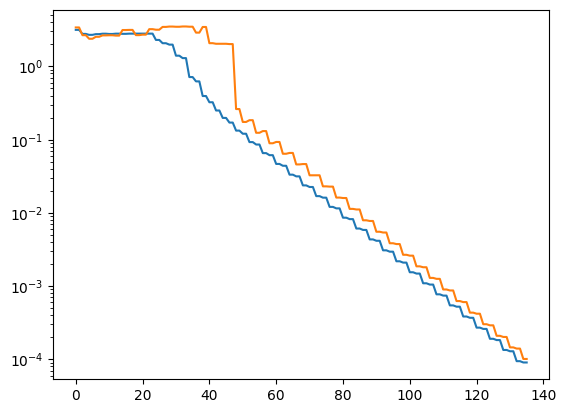

In [10]:
plt.semilogy(hoda.updates_[:,:hoda.iter_])
plt.show()

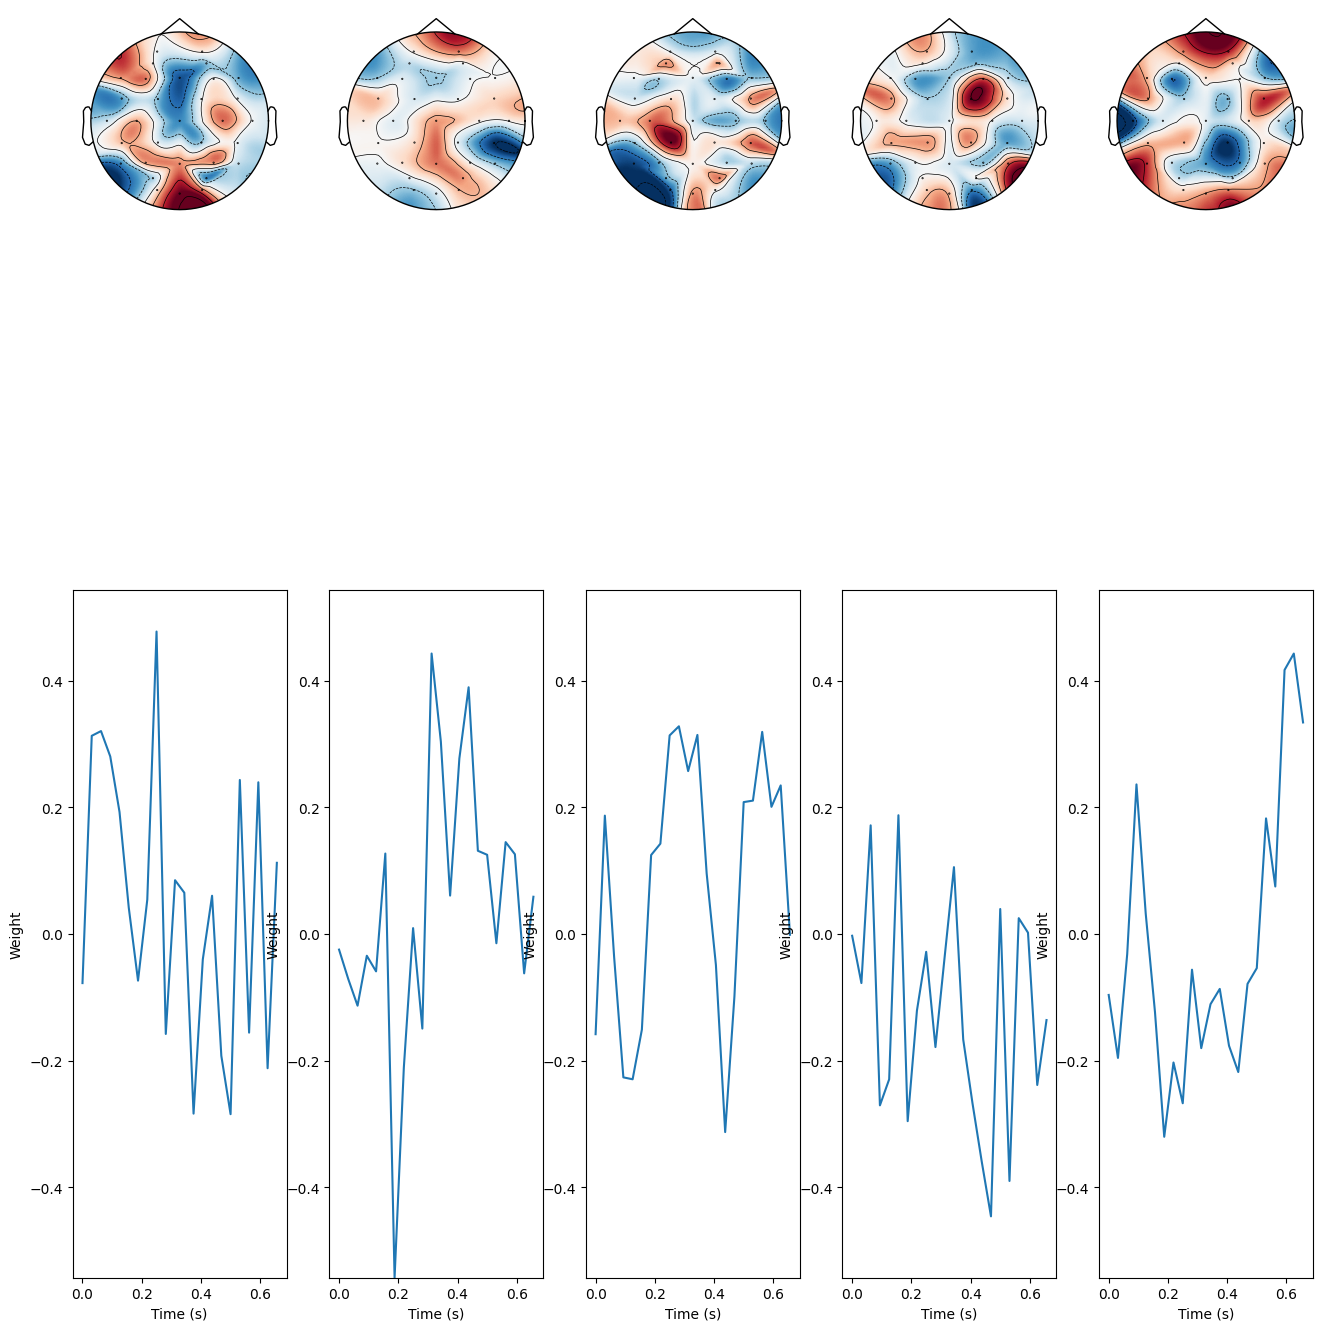

In [11]:

fig, axs = plt.subplots(2,hoda.rank, figsize=(16,6*3))
projs = [factors[k] @ p for k, p in enumerate(hoda.projs_)]
for i in range(hoda.rank):
    w = projs[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(projs[1]))
for i in range(hoda.rank):
    w = projs[1][:,i]
    axs[1,i].plot(epochs.times, w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])


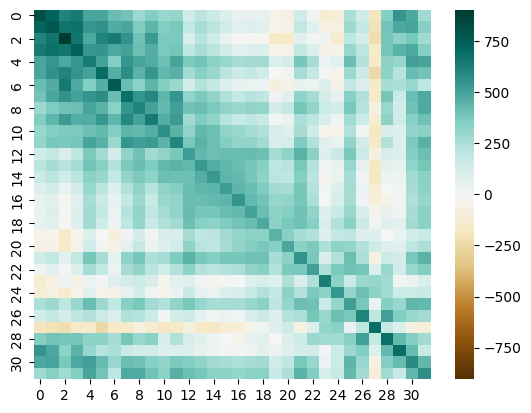

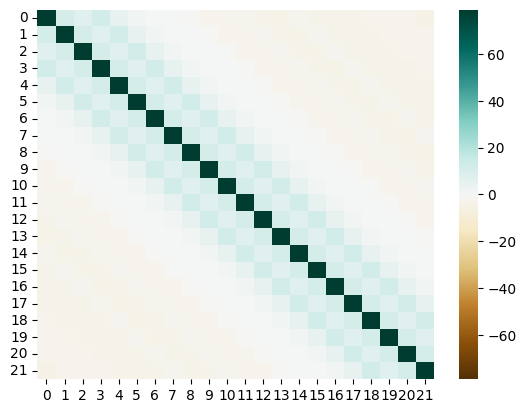

In [12]:
for k in range(2):
    cov = hoda.scatter_w_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

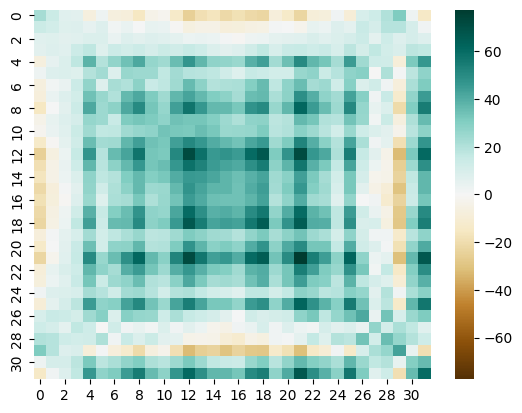

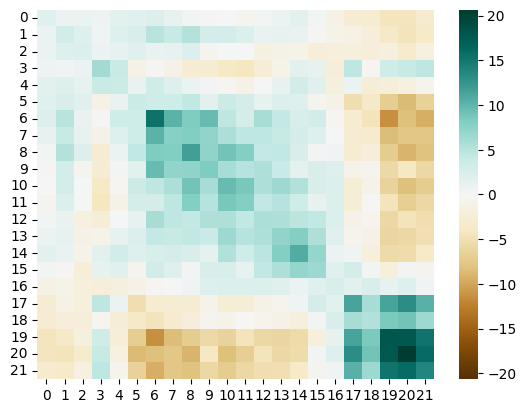

In [13]:
for k in range(2):
    cov = hoda.scatter_b_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

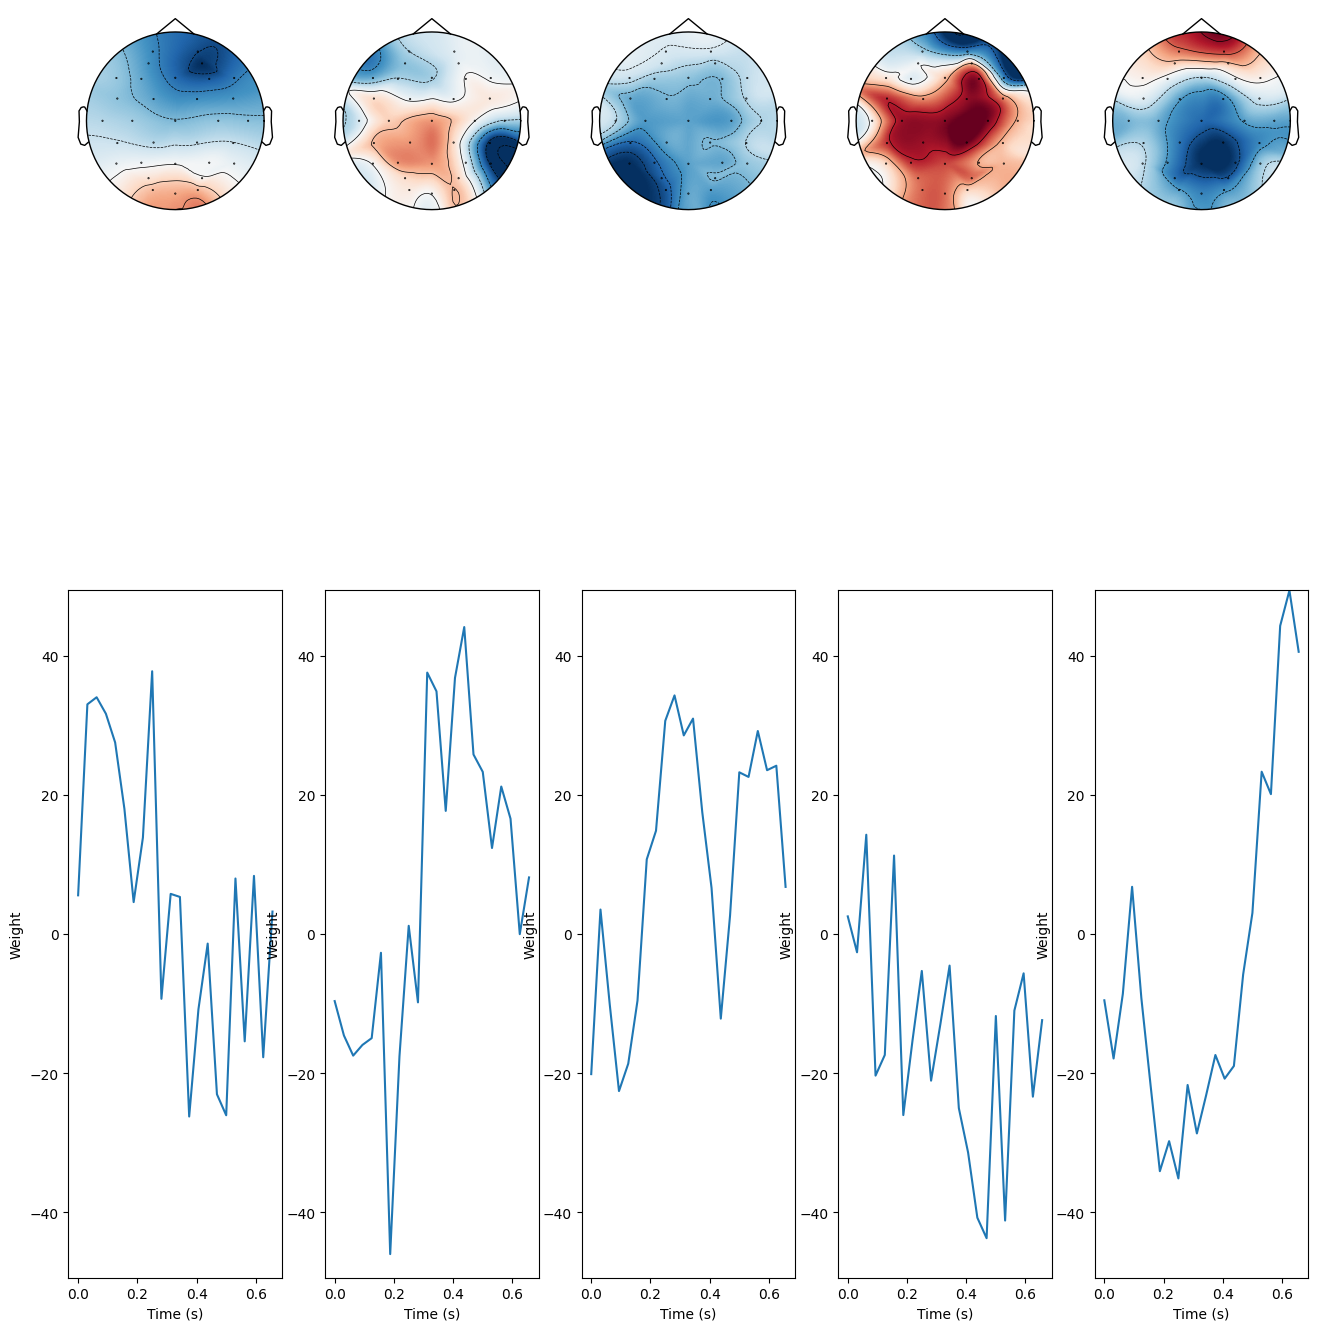

In [14]:
fig, axs = plt.subplots(2,hoda.rank, figsize=(16,6*3))
aps = [factors[k] @ hoda.scatter_w_[k] @ p for k,p in enumerate(hoda.projs_)]
for i in range(hoda.rank):
    w = aps[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank):
    w = aps[1][:,i]
    axs[1,i].plot(epochs.times, w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])

In [15]:
Xt_train = hoda.transform(X_train)
Xt_test = hoda.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

#classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)
classifier.fit(Xt_train,y_train)
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()

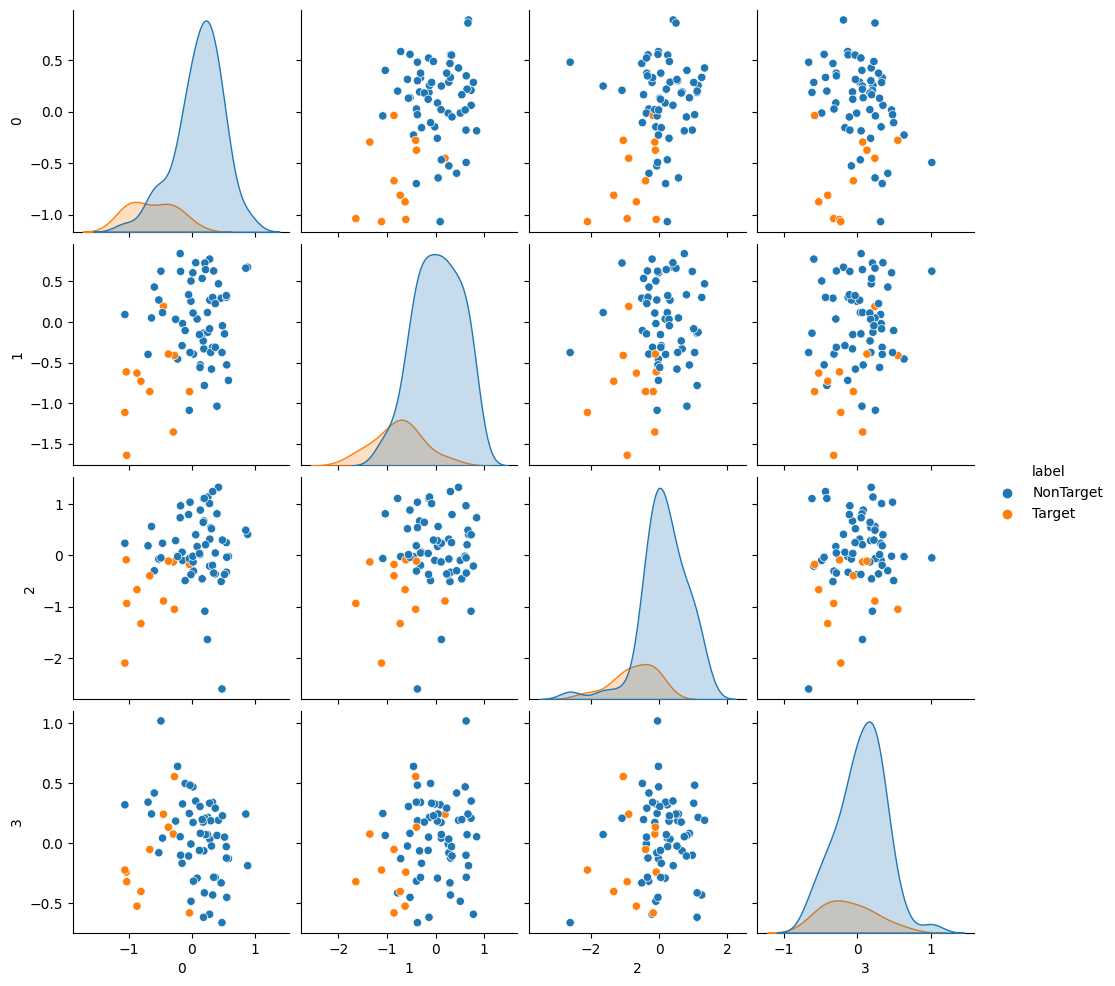

In [17]:
import seaborn as sns
import pandas as pd

n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
g = sns.pairplot(df_train, hue='label')

In [18]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.9984326018808777

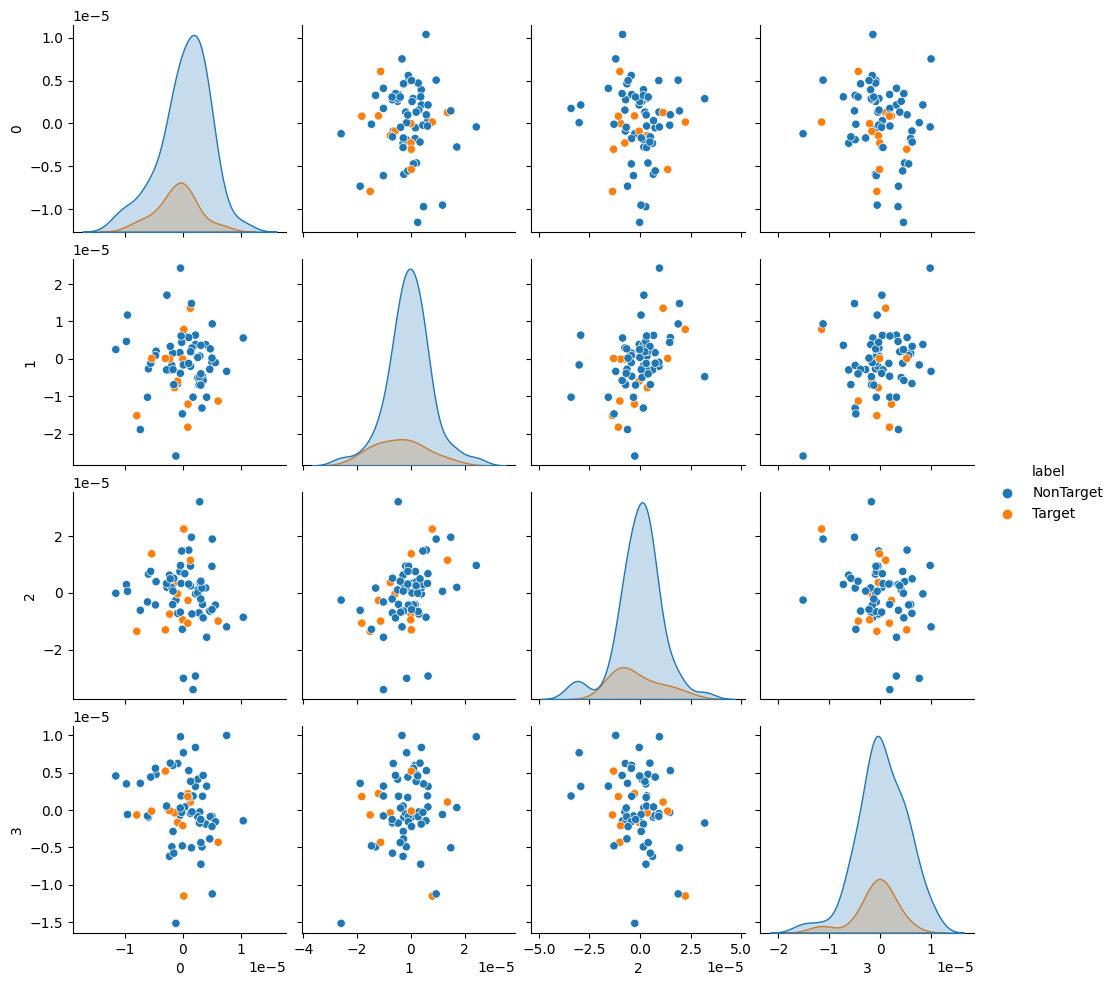

In [19]:
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
g = sns.pairplot(df_test, hue='label')

In [20]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.6345029239766082